<a href="https://colab.research.google.com/github/AIML-Dept/Adhisha_Sreedith_1GA23AI002/blob/main/Week_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install qiskit qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.7 MB/s eta 0:00:00


 **Easy: Install Qiskit and verify the installation by printing the Qiskit version
and available backends.**

In [4]:
import qiskit
from qiskit_aer import Aer

print("Qiskit Version:")
print(qiskit.__version__)

print("\nAvailable Backends:")

simulator = Aer.backends()

for backend in simulator:
    print(backend.name)

Qiskit Version:
2.5.1

Available Backends:
aer_simulator
aer_simulator_statevector
aer_simulator_density_matrix
aer_simulator_stabilizer
aer_simulator_matrix_product_state
aer_simulator_extended_stabilizer
aer_simulator_unitary
aer_simulator_superop
qasm_simulator
statevector_simulator
unitary_simulator


**Medium: Write a program to create a 1-qubit circuit, apply a Hadamard gate,
measure it, and execute 1024 shots on the simulator; plot the histogram.**

In [5]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(1,1)

qc.h(0)

qc.measure(0,0)

print(qc.draw())

simulator = AerSimulator()

compiled = transpile(qc, simulator)

job = simulator.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print("Counts:", counts)

plot_histogram(counts)

plt.show()

     ┌───┐┌─┐
  q: ┤ H ├┤M├
     └───┘└╥┘
c: 1/══════╩═
           0 
Counts: {'0': 519, '1': 505}


**Hard: Extend the circuit to 3 qubits in an equal superposition state and verify
the probability distribution matches theoretical expectations (uniform 1/8).**

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

qc = QuantumCircuit(3,3)

qc.h([0,1,2])

qc.measure([0,1,2],[0,1,2])

print(qc.draw())

sim = AerSimulator()

compiled = transpile(qc, sim)

job = sim.run(compiled, shots=1024)

result = job.result()

counts = result.get_counts()

print(counts)

shots = 1024

print("\nProbability Distribution")

for state in sorted(counts):
    print(state, counts[state]/shots)

plot_histogram(counts)

plt.show()

     ┌───┐┌─┐      
q_0: ┤ H ├┤M├──────
     ├───┤└╥┘┌─┐   
q_1: ┤ H ├─╫─┤M├───
     ├───┤ ║ └╥┘┌─┐
q_2: ┤ H ├─╫──╫─┤M├
     └───┘ ║  ║ └╥┘
c: 3/══════╩══╩══╩═
           0  1  2 
{'100': 121, '110': 135, '010': 136, '000': 125, '101': 125, '001': 129, '011': 138, '111': 115}

Probability Distribution
000 0.1220703125
001 0.1259765625
010 0.1328125
011 0.134765625
100 0.1181640625
101 0.1220703125
110 0.1318359375
111 0.1123046875


**Real-world: Simulate a simple random-number generator using qubit
superposition and compare its statistical randomness with Python's pseudorandom generator.**

Quantum Bits:
[0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0]
Python Bits:
[0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1]

Quantum
Zeros: 60
Ones : 40

Python
Zeros: 49
Ones : 51


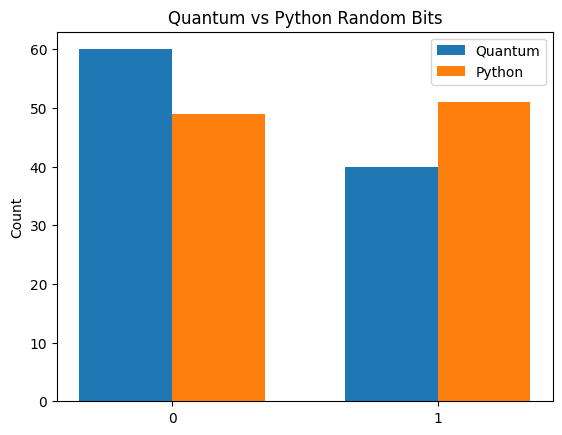

In [7]:
#Step 1: Import Libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
import random

#Step 2: Quantum Random Bit Function
simulator = AerSimulator()

def quantum_random_bit():
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)

    compiled = transpile(qc, simulator)
    job = simulator.run(compiled, shots=1)
    result = job.result()
    counts = result.get_counts()

    return int(list(counts.keys())[0])


#Step 3: Generate Quantum Random Bits
quantum_bits = []

for _ in range(100):
    quantum_bits.append(quantum_random_bit())

print("Quantum Bits:")
print(quantum_bits)

#Step 4: Generate Python Random Bits
python_bits = []

for _ in range(100):
    python_bits.append(random.randint(0, 1))

print("Python Bits:")
print(python_bits)

#Step 5: Compare Statistics
print("\nQuantum")
print("Zeros:", quantum_bits.count(0))
print("Ones :", quantum_bits.count(1))

print("\nPython")
print("Zeros:", python_bits.count(0))
print("Ones :", python_bits.count(1))

#Step 6: (Optional) Plot Comparison
import matplotlib.pyplot as plt

labels = ["0", "1"]

quantum_counts = [
    quantum_bits.count(0),
    quantum_bits.count(1)
]

python_counts = [
    python_bits.count(0),
    python_bits.count(1)
]

x = range(len(labels))
width = 0.35

plt.bar([i - width/2 for i in x], quantum_counts, width, label="Quantum")
plt.bar([i + width/2 for i in x], python_counts, width, label="Python")

plt.xticks(x, labels)
plt.ylabel("Count")
plt.title("Quantum vs Python Random Bits")
plt.legend()

plt.show()